<a href="https://colab.research.google.com/github/Richard-Palacio/Seminario-Ciencia-de-Datos/blob/main/Analisis_Exploratorio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# Importar librerías
import pandas as pd
import matplotlib.pyplot as plt #Permite graficar

In [14]:
# Carga de datos
data = pd.read_csv("dataset_banco.csv")

# **COMPRENSIÓN DEL DATASET**

## **Paso 1: Exploración inicial**

In [15]:
data.info()
data.head()
data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45215 entries, 0 to 45214
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45215 non-null  int64  
 1   job        45213 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45215 non-null  object 
 5   balance    45213 non-null  float64
 6   housing    45215 non-null  object 
 7   loan       45215 non-null  object 
 8   contact    45215 non-null  object 
 9   day        45215 non-null  int64  
 10  month      45215 non-null  object 
 11  duration   45214 non-null  float64
 12  campaign   45215 non-null  int64  
 13  pdays      45214 non-null  float64
 14  previous   45215 non-null  int64  
 15  poutcome   45215 non-null  object 
 16  y          45215 non-null  object 
dtypes: float64(3), int64(4), object(10)
memory usage: 5.9+ MB


,age,balance,day,duration,campaign,pdays,previous
count,45215.000000,45213.000000,45215.000000,45214.000000,45215.000000,45214.000000,45215.000000
mean,41.004711,1374.159866,15.805839,258.074357,2.763729,40.192485,0.580383
std,12.036647,3924.255525,8.322473,257.605175,3.097910,100.120622,2.303438
min,18.000000,-8019.000000,1.000000,-1389.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,776.000000,527532.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


### **Preguntas - Nivel descriptivo**

**1. ¿Cuántas observaciones y variables tiene el dataset?**
El dataset tiene:
45.215 observaciones (filas)
17 variables (columnas)

**2. ¿Qué tipos de variables existen (numéricas / categóricas)?**

Hay dos tipos principales:

Variables numéricas **7** (Son las que permiten cálculos matemáticos):
- age
- balance
- day
- duration
- campaign
- pdays
- previous

Variables categóricas **10** (Son las que representan categorías o textos):
- job
- marital
- education
- default
- housing
- loan
- contact
- month
- poutcome
- y

**3. ¿Cuál crees que es la variable más importante y por qué?**

La variable más importante puede ser **y**, ya que parece representar la variable objetivo (target) del dataset.

**4. ¿Qué variables parecen tener escalas muy diferentes?**

Las variables con escalas muy distintas son:

- age → máximo 776
- balance → máximo 527532
- duration → máximo 4918
- pdays → máximo 871
- previous → máximo 275

Ejemplo:

balance maneja cientos de miles
campaign solo llega a 63

**5. ¿Qué variables podrían requerir transformación?**

Podrían requerir transformación:

- **balance:** Porque tiene valores muy dispersos y extremos.
- **duration:** Porque incluso aparece un valor negativo (-1389), lo cual parece inconsistente.
- **age:** Porque el máximo 776 parece un error.

**Posibles transformaciones:**

- normalización
- estandarización
- tratamiento de outliers
- corrección de datos erróneos

### **Preguntas – Nivel crítico**

**6. ¿Qué información no puedes obtener solo con describe()?**

Con describe() no se puede saber:
- variables categoricas
- distribución visual de los datos
- correlaciones entre variables
- frecuencia de categorías
- valores atípicos visuales
- patrones ocultos
- datos erróneos contextuales

Por ejemplo, describe() muestra que age llega a 776, pero no explica si es error o caso real.

**7. ¿Por qué describe() no muestra variables categóricas?**

Porque describe() está diseñado principalmente para calcular estadísticas numéricas, como:

- promedio
- desviación estándar
- mínimo
- máximo

Estas operaciones solo tienen sentido en variables numéricas.

Las variables categóricas contienen texto o etiquetas (por ejemplo job, marital, education), y no se les puede calcular un promedio o una desviación estándar de forma directa.

**8. ¿Qué variable podría generar problemas si se analiza solo con promedios?**

Una variable que podría generar problemas si se analiza solo con promedios es balance ya que presenta una gran dispersión de valores:

- mínimo: -8019
- máximo: 527532
- media: 1374

Esto significa que existen valores extremadamente altos que pueden elevar mucho el promedio y hacer que no represente correctamente a la mayoría de los datos.

Por ejemplo: aunque el promedio es 1374, la mediana es 448, lo que muestra que la mayoría de clientes tiene balances mucho menores que algunos casos extremos.

## **Paso 2: Variable objetivo (sin modelar)**

In [16]:
data['y'].value_counts()
data['y'].value_counts(normalize=True)

,proportion
y,
no,0.883003
yes,0.116997


### **Preguntas – Interpretación**

**1. ¿Cuál es la clase mayoritaria?**

La clase mayoritaria en 'y' es no, porque representa la mayor cantidad de registros del dataset.

- no = 88.30%
- yes = 11.70%

**2. ¿Qué porcentaje representa la clase minoritaria?**

La clase minoritaria es yes y representa el 11.70%, Es decir, solo una pequeña parte de los clientes respondió positivamente.

**3. ¿Este comportamiento es realista en campañas bancarias?**

Sí, es un comportamiento bastante realista

En campañas bancarias normalmente:

- muchas personas rechazan ofertas
- pocas aceptan productos financieros

Es común que la respuesta positiva sea baja porque no todos los clientes tienen interés, capacidad económica o confianza para aceptar.

**4. ¿Qué riesgo existe si ignoramos la clase minoritaria?**

El principal riesgo es que el modelo o análisis ignore justamente los casos más importantes: los clientes que sí aceptan.

Si se ignora la clase yes:

- se pierde capacidad de identificar clientes potenciales
- el modelo puede predecir casi siempre no
- se afectan decisiones comerciales

Aunque yes sea minoritaria, es la clase de mayor interés para el negocio.

### **Preguntas – Pensamiento crítico**

**5. ¿Un dataset balanceado siempre representa mejor la realidad?**

No necesariamente.

Un dataset balanceado ayuda en modelos predictivos, pero no siempre refleja el comportamiento real.

En este caso, en la realidad bancaria normalmente hay más respuestas negativas que positivas.

**6. ¿Qué decisiones del negocio podrían verse afectadas por este desbalance?**

Puede afectar decisiones como:

- a que clientes dirigir campañas
- cuánto invertir en llamadas o publicidad
- que perfil de cliente priorizar

Si el análisis favorece demasiado la clase mayoritaria, se pueden perder oportunidades de venta.

**|7. ¿Qué variable podría estar relacionada con la clase “yes”?**

Una variable muy relacionada podría ser duration.

Porque la duración de la llamada suele influir en la aceptación:

- llamadas más largas pueden indicar interés
- llamadas muy cortas suelen terminar en rechazo

# **CALIDAD DE DATOS**

## **Paso 3: Análisis de valores faltantes**

In [17]:
data.isnull().sum()

,0
age,0
job,2
marital,1
education,1
default,0
balance,2
housing,0
loan,0
contact,0
day,0


### **Preguntas – Técnica**

**1. ¿Qué variables tienen valores faltantes?**

Las variables con valores faltantes son:

- job → 2 valores faltantes
- marital → 1 valor faltante
- education → 1 valor faltante
- balance → 2 valores faltantes
- duration → 1 valor faltante
- pdays → 1 valor faltante

En total hay faltantes en 6 variables con valores faltantes.

**2. ¿Qué porcentaje del dataset representan?**

El dataset tiene 45.215 registros, por lo tanto el porcentaje de faltantes es muy bajo.

Incluso sumando todos los faltantes (8 en total), menos del 0.02% del dataset presenta datos faltantes, lo cual es muy bajo. (0.0177% del dataset total)

**3. ¿Hay variables críticas con datos faltantes?**

Sí, algunas variables son importantes:

- balance
- duration
- pdays

Porque son variables numéricas que pueden influir en análisis predictivos.

También job y education son relevantes porque ayudan a segmentar clientes.

### **Preguntas – Decisión**

**4. ¿Eliminarías filas con NA? ¿Por qué?**

Sí, en este caso sería una decisión válida

Porque:

- el número de faltantes es muy pequeño
- eliminar esas filas no afecta significativamente el dataset

Al ser tan pocos casos, la pérdida de información es mínima.

**5. ¿Qué información podrías perder?**

Se perdería información puntual de algunos clientes, por ejemplo:

- ocupación
- nivel educativo
- saldo bancario
- duración de llamada

Aunque es poca información, cada registro representa un cliente real.

**6. ¿Imputarías todos los NA con la misma técnica?**

No.

Cada variable debe tratarse según su tipo:

*Variables categóricas (job, marital, education)*

Se puede usar: moda (valor más frecuente)

*Variables numéricas (balance, duration, pdays)*

Se puede usar: mediana o promedio (si no hay outliers fuertes)

No conviene usar una sola técnica para todo.

### **Preguntas – Ética y sesgo**

**7. ¿Eliminar NA podría introducir sesgo?**

Sí, eliminar valores faltantes puede introducir sesgo si esos datos no están distribuidos aleatoriamente.

Esto significa que, si los registros con NA pertenecen a clientes con características similares, al eliminarlos se estaría reduciendo la presencia de ese grupo en el análisis.

Aunque en este dataset el riesgo es bajo porque hay pocos NA, pero metodológicamente siempre debe revisarse antes de eliminarlos.

**8. ¿Qué tipo de clientes podrían quedar fuera del análisis?**

Podrían quedar fuera clientes que:

- no reportaron ocupación
- tienen información financiera incompleta
- tuvieron registros incompletos en campañas anteriores

Eso puede afectar ciertos segmentos específicos.

**9. ¿Esto afectaría la representatividad del dataset?**

En este caso el impacto sería muy bajo porque hay muy pocos NA.

Pero si los faltantes estuvieran concentrados en un grupo específico, sí podría afectar la representatividad.

## **Paso 4: Análisis de duplicados**

In [18]:
data.duplicated().sum()

np.int64(4)

### **Preguntas**

**1. ¿Existen duplicados?**

Sí, existen duplicados en el dataset.

arrojó 4, lo que significa que hay 4 filas completamente repetidas.

Esto indica que algunos registros tienen exactamente la misma información en todas sus variables.

**2. ¿Un duplicado siempre es un error?**

No, un duplicado no siempre significa error.

Puede ocurrir que:

- dos clientes tengan exactamente los mismos datos
- una campaña registre dos veces una interacción real
- el sistema haya guardado el mismo registro más de una vez

Por eso no se deben eliminar automáticamente sin analizar el contexto.

**3. ¿Qué información adicional necesitarías para decidir?**

Sería útil conocer:

- si existe un identificador único del cliente
- fecha exacta del registro
- número de contacto o campaña
- si cada fila representa una llamada o un cliente distinto

Sin un identificador único no se puede confirmar si realmente son errores.

**4. ¿Qué pasaría si eliminamos registros válidos?**

Si se eliminan registros válidos, se puede perder información real del comportamiento de clientes.

Esto puede afectar:

- frecuencias de respuesta
- proporciones de clases
- patrones de análisis

Incluso pocos registros pueden alterar resultados cuando pertenecen a casos importantes como la clase yes.

## **Paso 5: Análisis de outliers**

<Axes: xlabel='balance'>

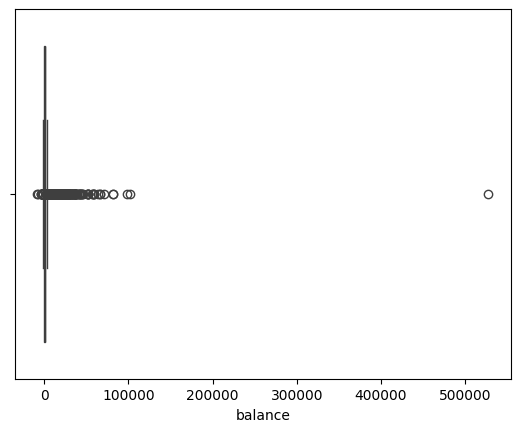

In [20]:
import seaborn as sns
sns.boxplot(x=data['balance'])

### **Preguntas – Observación**


**1. ¿Existen valores extremos?**

Sí, existen valores extremos (outliers).

Se observan muchos puntos fuera de los bigotes del boxplot, especialmente hacia valores altos.

Además aparece un caso extremadamente alejado alrededor de 500.000, que claramente está fuera del comportamiento general.

**2. ¿Son positivos, negativos o ambos?**

Son ambos:

- hay valores negativos (porque el mínimo era -8019)
- hay muchos valores positivos extremos

Sin embargo, los outliers positivos son mucho más grandes en magnitud.

**3. ¿El boxplot te permite ver todos los detalles?**

No completamente.

Porque al existir un valor extremadamente alto, el gráfico se comprime y la mayoría de datos queda muy concentrada. Esto dificulta observar bien la distribución central.

### **Preguntas – Estadística**

**4. ¿Cómo afectan los outliers a la media?**

Los outliers elevan fuertemente la media.

En este caso:

- media = 1374
- mediana = 448

Eso muestra que algunos valores muy altos están empujando el promedio hacia arriba.

**5. ¿La mediana se ve afectada?**

Muy poco.

La mediana es más resistente porque depende de la posición central y no del tamaño extremo de algunos valores.

**6. ¿Qué estadístico sería más confiable aquí?**

La mediana es más confiable

Porque representa mejor el centro real cuando hay valores extremos.

También los percentiles ayudan mucho en este caso.

### **Preguntas – Decisión**

**7. ¿Eliminarías los outliers? Justifica.**

No eliminaría los outliers de forma inmediata, porque primero es necesario analizar su origen y su significado dentro del contexto del dataset.

Por eso, antes de eliminarlos, conviene revisar:

- si el valor es coherente con otros datos del cliente
- si aparece con frecuencia similar en otros registros
- si afecta de forma excesiva el análisis estadístico

Una decisión más adecuada sería aplicar primero técnicas como:

- comparar con percentiles
- revisar rango intercuartílico (IQR)
- validar si son casos aislados o patrones reales

En este caso, eliminar directamente podría hacer que el análisis pierda información importante sobre clientes financieramente atípicos pero reales.

**8. ¿Podrían representar clientes reales?**

Sí, perfectamente.

Un cliente puede tener:

- alto saldo bancario
- inversiones
- cuentas empresariales

Por eso un valor extremo no siempre es incorrecto.

**9. ¿Qué riesgos existen al eliminarlos sin análisis?**

Eliminar outliers sin revisar puede:

- perder información valiosa
- alterar patrones reales del negocio
- reducir capacidad predictiva

Especialmente si esos clientes tienen comportamientos importantes en la variable y.

# **ACTIVIDAD DE DISCUSIÓN FINAL**

## **Eje 1 – Datos vs Decisiones**

**¿Qué decisiones de limpieza son más riesgosas?**

Una de las decisiones de limpieza más riesgosas es eliminar datos sin analizar su contexto. Por ejemplo, borrar valores faltantes, duplicados u outliers de forma automática puede parecer correcto técnicamente, pero puede hacer que se pierda información importante.

**¿Qué errores podrían afectar un modelo futuro?**

En este dataset, aunque los valores faltantes son muy pocos, eliminar registros sin revisar podría excluir ciertos perfiles de clientes. Lo mismo ocurre con los duplicados: no siempre significan error, porque dos clientes pueden compartir exactamente las mismas características.

También encontramos posibles errores que sí podrían afectar un modelo futuro, como valores poco realistas en variables numéricas, por ejemplo una edad de 776 años o una duración negativa de llamada. Ese tipo de registros puede distorsionar el aprendizaje de un modelo predictivo y generar conclusiones incorrectas.

## **Eje 2 – Estadística vs Realidad**


**¿Los outliers siempre son errores?**

Los outliers no siempre son errores. En la variable balance observamos valores extremadamente altos, pero en un contexto bancario eso puede representar clientes reales con altos ingresos, inversiones o grandes ahorros.

Por eso, antes de eliminar un valor extremo, es necesario analizar si es coherente con la realidad del negocio.

**¿La media es una buena medida para balance?**

En este caso, la media no es la mejor medida para balance, porque está muy afectada por esos valores extremos.

La **media** fue de **1374**, mientras que la **mediana** fue de **448**, lo que muestra que unos pocos valores altos elevan mucho el **promedio**.

Por eso, para esta variable la **mediana** es más confiable, porque representa mejor el comportamiento de la mayoría de clientes.

## **Eje 3 – Preparación para el futuro**


**¿Qué información adicional pedirías antes de modelar?**

Antes de modelar, sería importante contar con más información del contexto del dataset, por ejemplo:

- si cada fila representa un cliente o una llamada
- si existe un identificador único
- cómo se recolectaron los datos
- qué significa exactamente cada categoría

Esto ayudaría a tomar mejores decisiones de limpieza y selección de variables.

**¿Qué variable analizarías más a fondo?**

La variable que analizaría más a fondo es **duration**, porque suele tener relación directa con la respuesta final del cliente.

Una llamada más larga puede indicar mayor interés, por lo que podría estar asociada con la clase yes.

También revisaría **balance**, porque muestra mucha dispersión y puede influir bastante en los resultados.

# **CONCLUSION**

El análisis del dataset permitió identificar que, aunque la estructura general de los datos es adecuada, existen varios aspectos que deben revisarse antes de cualquier modelado. Se encontraron valores faltantes en algunas variables, aunque en una proporción muy baja, por lo que su impacto es reducido. También se detectaron registros duplicados, que requieren validación antes de ser eliminados, ya que podrían representar clientes o eventos reales. En las variables numéricas se observaron valores extremos, especialmente en balance, donde algunos registros presentan montos muy superiores al promedio. Esto demuestra que no todos los outliers deben considerarse errores, especialmente en un contexto bancario. Además, se identificaron valores atípicos que sí parecen inconsistentes, como una edad de 776 años o una duración negativa, lo que indica posibles errores de captura. La distribución de la variable objetivo muestra un desbalance importante entre clientes que aceptan y no aceptan la oferta bancaria, lo cual debe considerarse en etapas posteriores de modelado.

# **RECOMENDACION**

**¿Está el dataset listo para modelar?**

El dataset aún no está completamente listo para modelar

**¿Por qué?**

primero deben corregirse ciertos aspectos de calidad de datos.

Se recomienda:

- revisar valores imposibles o inconsistentes
- validar duplicados
- tratar variables con outliers extremos
- manejar adecuadamente el desbalance de la variable objetivo

Aunque la cantidad de valores faltantes es mínima, también es importante decidir cómo tratarlos según el tipo de variable.

Además, algunas variables categóricas deberán transformarse antes de ser usadas en modelos predictivos.

Después de estas correcciones, el dataset sí puede utilizarse de forma confiable.

# **MODELOS QUE SE PUEDEN APLICAR AL DATASET BANCARIO**

Como la variable objetivo y tiene dos clases (yes / no), este problema corresponde principalmente a clasificación supervisada.

Modelos que se pueden aplicar:
- **Logistic Regression:** Ideal para predecir probabilidad de aceptación.
- **Decision Tree:** Permite interpretar fácilmente qué variables influyen.
- **Random Forest:** Mejora precisión al combinar múltiples árboles.
- **K-Nearest Neighbors:** Clasifica clientes según similitud.
- **Support Vector Machine:** Útil en separación de clases.

También se podrían aplicar técnicas de:

- análisis de segmentación de clientes
- detección de patrones de comportamiento
- predicción de respuesta comercial

Antes de elegir el modelo, es clave preparar bien los datos, porque un buen modelo no corrige errores de origen.